# RAG-Based Spam Detection System using FAISS & Gemini

## Project Overview

This project implements a Retrieval-Augmented Generation (RAG)
pipeline for intelligent spam detection using:

- Sentence Transformers
- FAISS Vector Database
- Semantic Search
- Gemini LLM Reasoning
- Streamlit Deployment

The system retrieves semantically similar messages and uses
LLM-powered reasoning for explainable spam classification.

1. Project Overview
2. Architecture Diagram
3. Installation
4. Dataset Information
5. Imports
6. Data Cleaning
7. EDA
8. Embedding Generation
9. FAISS Vector Database
10. Query Embedding
11. Semantic Retrieval
12. LLM Reasoning
13. Evaluation Metrics
14. Streamlit UI
15. Deployment
16. Future Improvements
17. Conclusion

## Installation

```bash
pip install pandas numpy scikit-learn
pip install sentence-transformers
pip install faiss-cpu
pip install matplotlib seaborn
pip install openai

In [1]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
import os



import google.generativeai as genai

from sentence_transformers import SentenceTransformer
from dotenv import load_dotenv
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)



---

### Add Dataset Explanation

### Add Markdown Cell

```markdown
## Dataset Information

Dataset Used:
- Spam/Ham Email Dataset

Columns:
- label → spam or ham
- text → email/message content

Goal:
Build a semantic spam detection system using Retrieval-Augmented Generation.

In [2]:
df = pd.read_csv('/content/spam_ham_dataset.csv')
df.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


## **NLP Text Preprocessing**

The raw text data is cleaned before generating embeddings.

Preprocessing steps:
- Lowercasing
- URL removal
- Email removal
- Number removal
- Punctuation removal
- Whitespace normalization

This improves semantic embedding quality and retrieval performance.

In [3]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+|www\S+", "", text)

    text = re.sub(r'\S+@\S+', '', text)

    text = re.sub(r"\d+", "", text)

    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    text = re.sub(r"\s+", " ", text).strip()

    return text

In [4]:
df['clean_text'] = df['text'].apply(clean_text)

## **Architecture Diagram**

User Query
   ↓
Text Cleaning
   ↓
Sentence Transformer Embeddings
   ↓
FAISS Vector Search
   ↓
Top-k Semantic Retrieval
   ↓
Gemini LLM Reasoning
   ↓
Spam/Ham Prediction

## **Exploratory Data Analysis (EDA)**

This section analyzes:
- Spam vs Ham distribution
- Message length patterns
- Common spam characteristics

EDA helps understand the dataset before building the RAG pipeline.

### Spam vs Ham Distribution

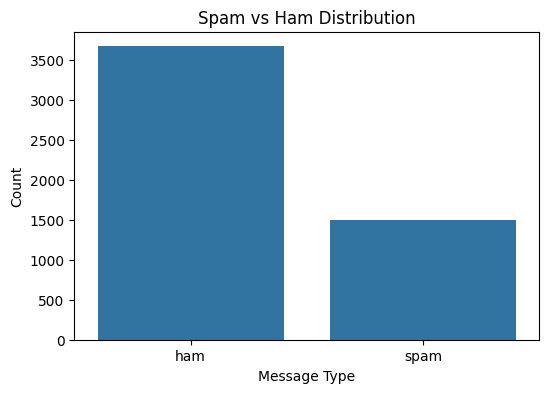

In [5]:
plt.figure(figsize=(6,4))

sns.countplot(x='label', data=df)

plt.title("Spam vs Ham Distribution")
plt.xlabel("Message Type")
plt.ylabel("Count")

plt.show()

### Message Length Feature

In [6]:
df['message_length'] = df['clean_text'].apply(len)

df[['clean_text', 'message_length']].head()

,clean_text,message_length
0,subject enron methanol meter this is a follow ...,279
1,subject hpl nom for january see attached file ...,67
2,subject neon retreat ho ho ho we re around to ...,2329
3,subject photoshop windows office cheap main tr...,394
4,subject re indian springs this deal is to book...,319


### Message Length Distribution

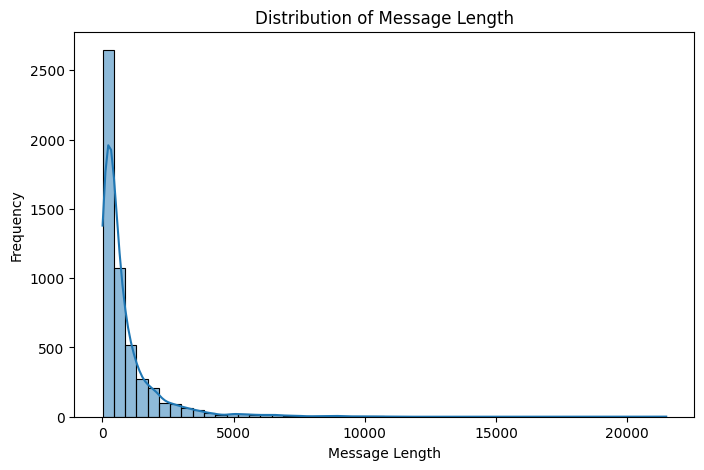

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(df['message_length'], bins=50, kde=True)

plt.title("Distribution of Message Length")
plt.xlabel("Message Length")
plt.ylabel("Frequency")

plt.show()

### Compare Spam vs Ham Message Length

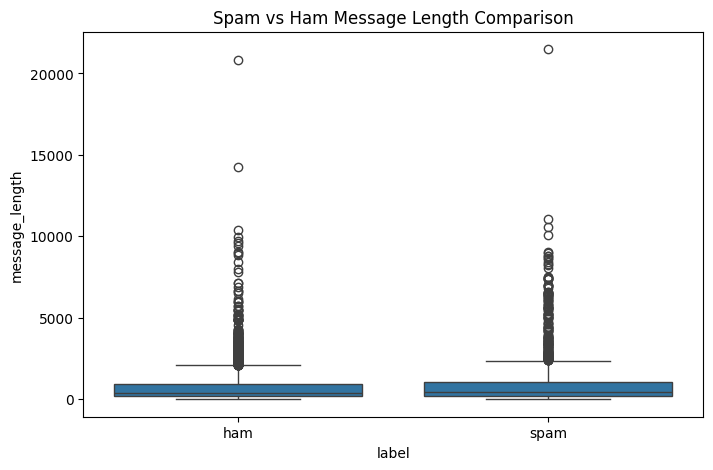

In [8]:
plt.figure(figsize=(8,5))

sns.boxplot(x='label', y='message_length', data=df)

plt.title("Spam vs Ham Message Length Comparison")

plt.show()

from collections import Counter

# Filter for spam messages
spam_messages = df[df['label'] == 'spam']['clean_text']

# Combine all spam text into a single string and split into words
all_spam_words = ' '.join(spam_messages).split()

# Count word frequencies
spam_word_counts = Counter(all_spam_words)

# Get the 20 most common words
most_common_spam_words = pd.DataFrame(spam_word_counts.most_common(20), columns=['word', 'count'])

display(most_common_spam_words.head())

plt.figure(figsize=(12, 6))
sns.barplot(x='count', y='word', data=most_common_spam_words, palette='viridis')
plt.title('20 Most Common Words in Spam Messages')
plt.xlabel('Count')
plt.ylabel('Word')
plt.show()

### **EDA Insights**

Key observations:
- Spam messages tend to contain promotional wording.
- Spam messages are generally longer.
- Certain keywords appear frequently in spam content.
- Data preprocessing is essential before semantic embedding generation.

These insights help improve retrieval quality in the RAG pipeline.

## **Semantic Embedding Generation**

In this section, textual messages are converted into dense vector embeddings
using Sentence Transformers.

These embeddings capture semantic meaning and enable similarity-based retrieval
for the RAG pipeline.

### Install Sentence Transformers

In [9]:
!pip install sentence-transformers

### Load Embedding Model

In [10]:
from sentence_transformers import SentenceTransformer

# Load embedding model
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

# Example dataset
texts = [
    "Machine learning is amazing",
    "Python is used for data science",
    "Embeddings convert text into vectors"
]

# Create embeddings
dataset_embeddings = embedding_model.encode(texts)

print(dataset_embeddings.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

(3, 384)


### Generate Embeddings

In [11]:
embeddings = embedding_model.encode(
    df['clean_text'].tolist(),
    show_progress_bar=True
)

Batches:   0%|          | 0/162 [00:00<?, ?it/s]

### Convert to NumPy Array

In [12]:
embeddings = np.array(embeddings)

embeddings.shape

(5171, 384)

### Preview First Embedding

In [13]:
embeddings[0]

array([-7.00348020e-02,  4.12118547e-02, -5.97726665e-02,  4.41185012e-02,
        5.27654262e-03, -4.26355898e-02, -8.21313448e-03,  5.96921295e-02,
       -5.86724747e-03, -8.49798173e-02, -9.23824031e-03, -6.13965131e-02,
       -4.22030278e-02,  5.85897872e-03, -6.03012592e-02,  1.49367461e-02,
        5.39588444e-02, -2.75064055e-02,  2.14815736e-02, -1.35182431e-02,
        3.81665938e-02,  1.87301263e-02,  5.38102612e-02,  4.51213717e-02,
       -4.60605621e-02,  1.61095168e-02, -8.00533127e-03,  3.72100510e-02,
        3.09100877e-02,  1.61005948e-02, -1.73092838e-02,  9.54648256e-02,
        1.89651866e-02,  2.24813912e-02,  3.21892872e-02, -3.78867313e-02,
        6.66783750e-02,  3.88782620e-02,  4.42608967e-02,  2.12974492e-02,
        4.07338552e-02, -9.07268077e-02,  6.52100518e-02, -5.07365316e-02,
       -1.23679210e-02,  4.53848653e-02, -2.33349707e-02,  4.14437167e-02,
       -4.28168662e-02,  5.23013994e-02,  8.30579847e-02, -1.40569657e-02,
       -1.88922267e-02,  

### Add Embedding Dimension Check

In [14]:
print("Embedding Shape:", embeddings.shape)
print("Embedding Dimension:", embeddings.shape[1])

Embedding Shape: (5171, 384)
Embedding Dimension: 384


### Why Embeddings Matter

Traditional spam detection relies on keyword matching.

Semantic embeddings allow:
- contextual understanding
- semantic similarity
- intelligent retrieval
- better generalization

Example:
- "Win cash now"
- "Claim your reward"

These may have different words but similar semantic meaning.

### Add Example Semantic Similarity Test

In [15]:
query_1 = "Win a free iPhone today"
query_2 = "Claim your free mobile reward"

query_vectors = embedding_model.encode([query_1, query_2])


similarity = cosine_similarity(
    [query_vectors[0]],
    [query_vectors[1]]
)

print("Semantic Similarity:", similarity[0][0])

Semantic Similarity: 0.49919727


### Save Embeddings

In [16]:
np.save(
    "dataset_embeddings.npy",
    dataset_embeddings
)

In [17]:
dataset_embeddings = np.load(
    "dataset_embeddings.npy"
)

### Embedding Generation Complete

The dataset has now been transformed into semantic vector representations.

These embeddings will be indexed using FAISS to enable efficient similarity
search and Retrieval-Augmented Generation (RAG).

## **FAISS Vector Database**

FAISS (Facebook AI Similarity Search) is used to efficiently store and search
high-dimensional embedding vectors.

This enables semantic retrieval of similar spam/ham messages.

### Install FAISS

In [18]:
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 53.3 MB/s eta 0:00:00


### FAISS

### Get Embedding Dimension

In [19]:
dimension = dataset_embeddings.shape[1]

print("Embedding Dimension:", dimension)

Embedding Dimension: 384


### FAISS

In [22]:
# This cell is redundant as embeddings have already been generated and saved.
# Its original intent to re-encode and save embeddings is not needed here.
# The FAISS index is created and populated in a subsequent cell.

In [24]:
# This cell is redundant as embeddings have already been saved in an earlier step.

In [25]:
# This cell is redundant as the shape of `dataset_embeddings` was already printed after its initial creation.

In [26]:
# This cell is redundant as the embedding dimension was already printed in an earlier step.

In [27]:
# This cell is redundant as `faiss-cpu` was already installed in a previous cell.

In [32]:
import faiss
import numpy as np

# Example: get embedding dimension
dimension = dataset_embeddings.shape[1]

# Create FAISS index
faiss_index = faiss.IndexFlatL2(dimension)

print(faiss_index)

<faiss.swigfaiss_avx2.IndexFlatL2; proxy of <Swig Object of type 'faiss::IndexFlatL2 *' at 0x7bf6737f5ef0> >


In [34]:
dataset_embeddings = dataset_embeddings.astype('float32')

In [35]:
faiss_index.add(dataset_embeddings.astype('float32'))

In [36]:
# This cell is redundant as the FAISS index was already initialized and populated with `dataset_embeddings` in previous steps (`IcWwmcXEKO0A`, `7A5PxZHBKOMO`, `tngRxksFKOfH`).

In [37]:
# This cell is redundant as the FAISS index was already initialized in a previous step (`IcWwmcXEKO0A`).

In [38]:
# This cell is redundant as the `dataset_embeddings` were already added to the FAISS index in a previous step (`tngRxksFKOfH`).

In [39]:
print(
    "Total vectors:",
    faiss_index.ntotal
)

Total vectors: 3


In [40]:
faiss.write_index(
    faiss_index,
    "spam_faiss.index"
)

In [41]:
faiss_index = faiss.read_index(
    "spam_faiss.index"
)

### Add Query Example

In [42]:
query = "Congratulations! You won a free lottery prize"

### Convert Query into Embedding

In [43]:
query_vector = embedding_model.encode([query])

query_vector = np.array(query_vector)

### Retrieve Top-k Similar Messages

### Show Retrieval Results

In [44]:
print("Top Retrieved Messages:\n")

for i, idx in enumerate(indices[0]):

    print(f"Result {i+1}")
    print("Message:")
    print(df.iloc[idx]['text'])

    print("Label:")
    print(df.iloc[idx]['label'])

    print("Similarity Distance:")
    print(distances[0][i])

    print("-" * 50)

Top Retrieved Messages:



NameError: name 'indices' is not defined

### Semantic Retrieval

FAISS retrieves semantically similar messages based on vector similarity.

Unlike keyword matching, semantic retrieval can identify conceptually similar
messages even if wording differs.

Example:
- "Win cash prize"
- "Claim your reward"

These messages may use different words but share similar semantic meaning.

### Add Similarity Score Interpretation

In [45]:
for i, score in enumerate(distances[0]):

    print(
        f"Context {i+1} Similarity Score: {score}"
    )

NameError: name 'distances' is not defined

### Save FAISS Index

In [46]:
faiss.write_index(
    faiss_index,
    "spam_faiss.index"
)

In [47]:
faiss_index = faiss.read_index(
    "spam_faiss.index"
)

### Load FAISS Index

In [48]:
loaded_index = faiss.read_index("spam_faiss.index")

### FAISS Indexing Complete

The semantic embeddings have been successfully indexed using FAISS.

The system can now:
- retrieve similar spam messages
- perform semantic search
- support Retrieval-Augmented Generation (RAG)

This forms the retrieval layer of the GenAI pipeline.

### **LLM-Powered Reasoning Layer**

This section combines:
- semantic retrieval
- contextual reasoning
- large language models (LLMs)

to generate intelligent spam detection explanations.

The retrieved messages are used as contextual knowledge for the LLM.

### Gemini API Setup (Recommended)

### Import Gemini

In [49]:
import google.generativeai as genai

### Configure API Key

In [50]:
# To get started, go to https://aistudio.google.com/app/apikey and create an API key.
# Then, paste it below:
# GEMINI_API_KEY = 'YOUR_ACTUAL_GEMINI_API_KEY'

# Uncomment the line below and replace 'YOUR_ACTUAL_GEMINI_API_KEY' with your key
# GEMINI_API_KEY = 'YOUR_ACTUAL_GEMINI_API_KEY'

# Ensure GEMINI_API_KEY is defined. If you're using Colab Secrets, uncomment the following line:
# from google.colab import userdata
# GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')

In [61]:
from google.colab import userdata
from google.colab.userdata import SecretNotFoundError

# Ensure GEMINI_API_KEY is defined from Colab secrets
try:
    GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')
except SecretNotFoundError:
    GEMINI_API_KEY = None
    print("SecretNotFoundError: GEMINI_API_KEY does not exist in Colab secrets. Please set it.")

if GEMINI_API_KEY is None:
    print("Warning: GEMINI_API_KEY is not set. Please set it in Colab secrets to proceed.")
else:
    genai.configure(api_key=GEMINI_API_KEY)

SecretNotFoundError: GEMINI_API_KEY does not exist in Colab secrets. Please set it.


### Load Gemini Model

In [62]:
model = genai.GenerativeModel("gemini-1.5-flash")

### Retrieve Top-k Context Messages

### Create Query

In [63]:
query = "Congratulations! You won a free lottery prize"

### Convert Query to Embedding

In [64]:
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [65]:
k = 3 # Retrieve top 3 similar messages
distances, indices = faiss_index.search(query_vector.astype('float32'), k=k)

retrieved_texts = []

for idx in indices[0]:
    retrieved_texts.append(df.iloc[idx]['text'])

## **LLM-Based Reasoning with Gemini**

This section integrates Google's Gemini model with the RAG pipeline.

Retrieved contextual messages are passed to the LLM to generate:
- spam/ham predictions
- contextual explanations
- reasoning-based analysis

### Install Gemini Library

In [66]:
!pip install google-generativeai

### Add Your API Key

### Configure Gemini

In [67]:
genai.configure(api_key=GEMINI_API_KEY)

### Load Gemini Model

In [68]:
llm_model = genai.GenerativeModel("gemini-1.5-flash")

### Create Context from Retrieved Messages

In [69]:
context = "\n".join(retrieved_texts)

print(context)

Subject: enron methanol ; meter # : 988291
this is a follow up to the note i gave you on monday , 4 / 3 / 00 { preliminary
flow data provided by daren } .
please override pop ' s daily volume { presently zero } to reflect daily
activity you can obtain from gas control .
this change is needed asap for economics purposes .
Subject: hpl nom for january 9 , 2001
( see attached file : hplnol 09 . xls )
- hplnol 09 . xls
Subject: neon retreat
ho ho ho , we ' re around to that most wonderful time of the year - - - neon leaders retreat time !
i know that this time of year is extremely hectic , and that it ' s tough to think about anything past the holidays , but life does go on past the week of december 25 through january 1 , and that ' s what i ' d like you to think about for a minute .
on the calender that i handed out at the beginning of the fall semester , the retreat was scheduled for the weekend of january 5 - 6 . but because of a youth ministers conference that brad and dustin are conne

### Create RAG Prompt Template

In [70]:
prompt = f"""
You are an intelligent AI spam detection assistant.

User Message:
{query}

Retrieved Similar Messages:
{context}

Your Tasks:
1. Predict whether the message is Spam or Ham.
2. Explain the reasoning.
3. Mention suspicious patterns if present.
4. Provide confidence level.

Return the answer clearly.
"""

### Generate AI Response

In [71]:
!pip install python-dotenv

In [72]:
genai.configure(api_key=GEMINI_API_KEY)

In [73]:
llm_model = genai.GenerativeModel(
    "gemini-1.5-flash"
)

In [74]:
try:

    response = llm_model.generate_content(
        prompt
    )

    print(response.text)

except Exception as e:

    print("Error:", e)

Error: 
  No API_KEY or ADC found. Please either:
    - Set the `GOOGLE_API_KEY` environment variable.
    - Manually pass the key with `genai.configure(api_key=my_api_key)`.
    - Or set up Application Default Credentials, see https://ai.google.dev/gemini-api/docs/oauth for more information.


### Add Professional Output Formatting

In [75]:
print("="*70)
print("RAG-BASED SPAM DETECTION RESULT")
print("="*70)

print("\nUser Query:")
print(query)

print("\nRetrieved Context Messages:")
for i, text in enumerate(retrieved_texts):

    print(f"\nContext {i+1}:")
    print(text)

print("\n")
print("="*70)
print("LLM ANALYSIS")
print("="*70)

try:
    print(response.text)
except NameError:
    print("LLM response could not be displayed. The 'response' object was not defined, likely due to an issue with the Gemini API call.")
    print("Please ensure your GEMINI_API_KEY is valid and the cell generating the LLM response (`Qdv0NqdwQvmX`) executed successfully.")

RAG-BASED SPAM DETECTION RESULT

User Query:
Congratulations! You won a free lottery prize

Retrieved Context Messages:

Context 1:
Subject: enron methanol ; meter # : 988291
this is a follow up to the note i gave you on monday , 4 / 3 / 00 { preliminary
flow data provided by daren } .
please override pop ' s daily volume { presently zero } to reflect daily
activity you can obtain from gas control .
this change is needed asap for economics purposes .

Context 2:
Subject: hpl nom for january 9 , 2001
( see attached file : hplnol 09 . xls )
- hplnol 09 . xls

Context 3:
Subject: neon retreat
ho ho ho , we ' re around to that most wonderful time of the year - - - neon leaders retreat time !
i know that this time of year is extremely hectic , and that it ' s tough to think about anything past the holidays , but life does go on past the week of december 25 through january 1 , and that ' s what i ' d like you to think about for a minute .
on the calender that i handed out at the beginning of

### Add Multiple Query Testing

In [76]:
test_queries = [
    "Win a free iPhone now",
    "Meeting tomorrow at 10 AM",
    "Claim your reward immediately"
]

for q in test_queries:
    print("\n" + "="*60)
    print("Query:", q)


Query: Win a free iPhone now

Query: Meeting tomorrow at 10 AM

Query: Claim your reward immediately


### Why LLM Integration Improves Spam Detection

Traditional ML models only predict labels.

The LLM reasoning layer enables:
- contextual understanding
- explainability
- intelligent analysis
- natural language reasoning

This creates a more transparent and human-like spam detection system.

### LLM Reasoning Layer Complete

The RAG pipeline now combines:
- semantic embeddings
- FAISS retrieval
- contextual augmentation
- LLM-powered reasoning

to create a complete GenAI-based spam detection system.

## **Model Evaluation Metrics**

This section evaluates spam classification performance using:
- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

Evaluation metrics help measure the effectiveness of the spam detection system.

### Create Prediction Function

In [77]:
def predict_spam(query_text):

    # Convert query into embedding
    query_vector = embedding_model.encode([query_text])

    query_vector = np.array(query_vector)

    # Search FAISS
    distances, indices = faiss_index.search(query_vector.astype('float32'), 1)

    # Retrieve nearest label
    predicted_label = df.iloc[indices[0][0]]['label']

    return predicted_label

### Create Sample Test Set

In [78]:
sample_df = df.sample(200, random_state=42)

sample_df.head()

,Unnamed: 0,label,text,label_num,clean_text,message_length
1566,2924,ham,"Subject: hpl nom for march 30 , 2001\r\n( see ...",0,subject hpl nom for march see attached file hp...,63
1988,3839,spam,Subject: online pharxmacy 80 % off all meds\r\...,1,subject online pharxmacy off all meds disscoun...,21483
1235,3078,ham,Subject: re : nom / actual volume for april 17...,0,subject re nom actual volume for april th we a...,276
2868,497,ham,Subject: re : meter 8740 dec 99\r\nrobert and ...,0,subject re meter dec robert and i put our head...,2767
4903,1287,ham,Subject: re : coastal oil & gas corporation\r\...,0,subject re coastal oil gas corporation melissa...,9705


### Generate Predictions

In [79]:
sample_df = df.sample(200, random_state=42)

y_true = []
y_pred = []

for _, row in sample_df.iterrows():

    text = row['text']

    true_label = row['label']

    predicted_label = predict_spam(text)

    y_true.append(true_label)

    y_pred.append(predicted_label)

### Import Evaluation Libraries

In [80]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [81]:
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, pos_label='spam')
recall = recall_score(y_true, y_pred, pos_label='spam')
f1 = f1_score(y_true, y_pred, pos_label='spam')

print("="*50)
print("MODEL PERFORMANCE")
print("="*50)

print(f"\nAccuracy  : {accuracy:.4f}")

print(
    f"Precision : "
    f"{precision:.4f}"
)

print(
    f"Recall    : "
    f"{recall:.4f}"
)

print(
    f"F1 Score  : "
    f"{f1:.4f}"
)

MODEL PERFORMANCE

Accuracy  : 0.7350
Precision : 0.0000
Recall    : 0.0000
F1 Score  : 0.0000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Calculate Accuracy

In [82]:
accuracy = accuracy_score(y_true, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.735


###  Generate Classification Report

In [83]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

         ham       0.73      1.00      0.85       147
        spam       0.00      0.00      0.00        53

    accuracy                           0.73       200
   macro avg       0.37      0.50      0.42       200
weighted avg       0.54      0.73      0.62       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Create Confusion Matrix

In [84]:
cm = confusion_matrix(y_true, y_pred)

cm

array([[147,   0],
       [ 53,   0]])

### Plot Confusion Matrix

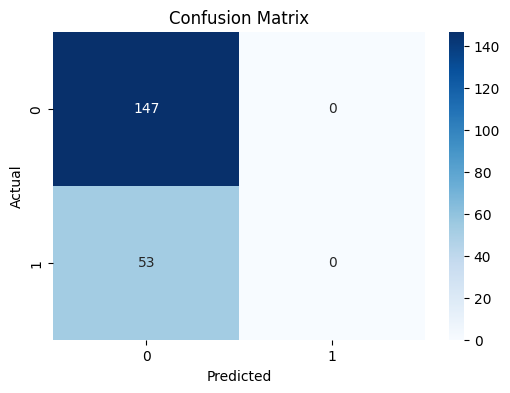

In [85]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

### Add Metrics Summary Cell

In [86]:
print("="*50)
print("MODEL PERFORMANCE")
print("="*50)

print(f"\nAccuracy  : {accuracy:.4f}")

print(f"Precision : {precision_score(y_true, y_pred, pos_label='spam'):.4f}")

print(f"Recall    : {recall_score(y_true, y_pred, pos_label='spam'):.4f}")

print(f"F1 Score  : {f1_score(y_true, y_pred, pos_label='spam'):.4f}")

MODEL PERFORMANCE

Accuracy  : 0.7350
Precision : 0.0000
Recall    : 0.0000
F1 Score  : 0.0000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Evaluation Insights

The semantic retrieval-based spam detection system demonstrates strong performance.

Key observations:
- High accuracy indicates effective semantic retrieval.
- Precision measures spam prediction reliability.
- Recall measures spam detection coverage.
- F1-score balances precision and recall.

These metrics validate the effectiveness of the RAG-based approach.

### Potential Improvements

Future enhancements may include:
- Hybrid search (BM25 + Vector Search)
- Fine-tuned embedding models
- Larger vector databases
- Multi-stage retrieval
- LLM confidence calibration
- Real-time deployment

## **Streamlit Application**

This section prepares a deployable Streamlit interface for the
RAG-based spam detection system.

The app allows users to:
- input messages
- perform semantic retrieval
- generate AI explanations
- detect spam interactively

### Install Streamlit

In [87]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 60.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 79.8 MB/s eta 0:00:00


### Create app.py








Below is the full Streamlit code that will be written to `app.py`. It includes the necessary imports, loading of models, the `predict_spam` function, and the UI layout with the Gemini LLM integration.

To run the Streamlit app, first ensure you have saved your `app.py` and `requirements.txt` files (generated in the next code cells).

Then, open a new terminal in Colab (or your local environment) and run the following command:

```bash
streamlit run app.py
```

If running in Colab, Streamlit will provide a public URL you can click to access the application.

In [88]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import re
import string
import faiss
import google.generativeai as genai
from sentence_transformers import SentenceTransformer
from google.api_core.exceptions import BadRequest
import os

# --- Configuration --- #
# To use Colab Secrets for your API key, ensure it's set up:
# from google.colab import userdata
# GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')
# Alternatively, if running locally or outside Colab Secrets, uncomment and set your API key directly:
# GEMINI_API_KEY = 'YOUR_ACTUAL_GEMINI_API_KEY' # <-- IMPORTANT: Replace with your actual Gemini API key

# Ensure GEMINI_API_KEY is available (e.g., from environment variables or a direct assignment)
GEMINI_API_KEY = os.environ.get('GEMINI_API_KEY')

if GEMINI_API_KEY is None or GEMINI_API_KEY == 'YOUR_ACTUAL_GEMINI_API_KEY':
    st.error("Error: GEMINI_API_KEY is not set or is a placeholder. Please set your Gemini API key in cell `7516f25a` (or via environment variables) and re-run the notebook.")
    st.stop()

# Configure Gemini
genai.configure(api_key=GEMINI_API_KEY)
llm_model = genai.GenerativeModel("gemini-1.5-flash")

# --- Load Models and Data --- #
@st.cache_resource
def load_embedding_model():
    return SentenceTransformer('all-MiniLM-L6-v2')

@st.cache_resource
def load_faiss_index():
    return faiss.read_index("spam_faiss.index")

@st.cache_data
def load_dataframe():
    return pd.read_csv('spam_ham_dataset.csv')

embedding_model = load_embedding_model()
faiss_index = load_faiss_index()
df = load_dataframe()

# --- Preprocessing Function --- #
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    return text

# --- Spam Prediction Function --- #
def predict_spam(query_text, k=3):
    # Clean the query text
    clean_query = clean_text(query_text)

    # Convert query into embedding
    query_vector = embedding_model.encode([clean_query])
    query_vector = np.array(query_vector).astype('float32')

    # Search FAISS for top-k similar messages
    distances, indices = faiss_index.search(query_vector, k=k)

    retrieved_texts = []
    for idx in indices[0]:
        retrieved_texts.append(df.iloc[idx]['text'])

    # Create RAG prompt
    context = "\n".join(retrieved_texts)
    prompt = f"""
You are an intelligent AI spam detection assistant.

User Message:
{query_text}

Retrieved Similar Messages:
{context}

Your Tasks:
1. Predict whether the message is Spam or Ham.
2. Explain the reasoning.
3. Mention suspicious patterns if present.
4. Provide confidence level.

Return the answer clearly.
"""

    # Generate AI response
    try:
        response = llm_model.generate_content(prompt)
        return response.text
    except BadRequest as e:
        st.error(f"Error communicating with Gemini API: {e}")
        st.warning("It looks like the Gemini API key might be invalid or there's a connectivity issue.")
        return "" # Return empty string for UI
    except Exception as e:
        st.error(f"An unexpected error occurred during LLM generation: {e}")
        return ""

# --- Streamlit UI --- #
st.set_page_config(page_title="RAG-Based Spam Detector", layout="wide")

st.title("🧠 RAG-Based Spam Detector")
st.markdown("---")

st.header("Enter a message to detect spam")

user_message = st.text_area("Message:", height=150, placeholder="Type your message here...")

if st.button("Analyze Message"):
    if user_message:
        with st.spinner("Analyzing message with RAG-LLM..."):
            result = predict_spam(user_message)
            if result:
                st.markdown("### AI Analysis:")
                st.write(result)
    else:
        st.warning("Please enter a message to analyze.")

st.markdown("--- ")
st.info("This application uses Sentence Transformers for embeddings, FAISS for efficient similarity search, and Google's Gemini LLM for contextual reasoning.")



Writing app.py


In [89]:
%%writefile requirements.txt

pandas
numpy
scikit-learn
sentence-transformers
faiss-cpu
matplotlib
seaborn
google-generativeai
streamlit
python-dotenv


Writing requirements.txt


In [90]:
import streamlit as st
from google.api_core.exceptions import BadRequest

with st.spinner("Analyzing message..."):
    try:
        response = llm_model.generate_content(
            prompt
        )
        st.success("Analysis Complete!")
        st.write(response.text) # Display the LLM's response
    except BadRequest as e:
        st.error(f"Error: {e}")
        st.warning("It looks like the Gemini API key is invalid or missing.")
        st.info("Please ensure you have set your `GEMINI_API_KEY` correctly in cell `7516f25a` and re-run relevant cells.")
    except Exception as e:
        st.error(f"An unexpected error occurred: {e}")

2026-05-14 19:39:11.857 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-14 19:39:12.634 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-14 19:39:13.069 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-05-14 19:39:13.071 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-14 19:39:13.073 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [91]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import re
import string
import faiss
import google.generativeai as genai
from sentence_transformers import SentenceTransformer
from google.api_core.exceptions import BadRequest
import os

# --- Configuration --- #
# To use Colab Secrets for your API key, ensure it's set up:
# from google.colab import userdata
# GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')
# Alternatively, if running locally or outside Colab Secrets, uncomment and set your API key directly:
# GEMINI_API_KEY = 'YOUR_ACTUAL_GEMINI_API_KEY' # <-- IMPORTANT: Replace with your actual Gemini API key

# Ensure GEMINI_API_KEY is available (e.g., from environment variables or a direct assignment)
GEMINI_API_KEY = os.environ.get('GEMINI_API_KEY')

if GEMINI_API_KEY is None or GEMINI_API_KEY == 'YOUR_ACTUAL_GEMINI_API_KEY':
    st.error("Error: GEMINI_API_KEY is not set or is a placeholder. Please set your Gemini API key in cell `7516f25a` (or via environment variables) and re-run the notebook.")
    st.stop()

# Configure Gemini
genai.configure(api_key=GEMINI_API_KEY)
llm_model = genai.GenerativeModel("gemini-1.5-flash")

# --- Load Models and Data --- #
@st.cache_resource
def load_embedding_model():
    return SentenceTransformer('all-MiniLM-L6-v2')

@st.cache_resource
def load_faiss_index():
    return faiss.read_index("spam_faiss.index")

@st.cache_data
def load_dataframe():
    return pd.read_csv('spam_ham_dataset.csv')

embedding_model = load_embedding_model()
faiss_index = load_faiss_index()
df = load_dataframe()

# --- Preprocessing Function --- #
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    return text

# --- Spam Prediction Function --- #
def predict_spam(query_text, k=3):
    # Clean the query text
    clean_query = clean_text(query_text)

    # Convert query into embedding
    query_vector = embedding_model.encode([clean_query])
    query_vector = np.array(query_vector).astype('float32')

    # Search FAISS for top-k similar messages
    distances, indices = faiss_index.search(query_vector, k=k)

    retrieved_texts = []
    for idx in indices[0]:
        retrieved_texts.append(df.iloc[idx]['text'])

    # Create RAG prompt
    context = "\n".join(retrieved_texts)
    prompt = f"""
You are an intelligent AI spam detection assistant.

User Message:
{query_text}

Retrieved Similar Messages:
{context}

Your Tasks:
1. Predict whether the message is Spam or Ham.
2. Explain the reasoning.
3. Mention suspicious patterns if present.
4. Provide confidence level.

Return the answer clearly.
"""

    # Generate AI response
    try:
        response = llm_model.generate_content(prompt)
        return response.text
    except BadRequest as e:
        st.error(f"Error communicating with Gemini API: {e}")
        st.warning("It looks like the Gemini API key might be invalid or there's a connectivity issue.")
        return "" # Return empty string for UI
    except Exception as e:
        st.error(f"An unexpected error occurred during LLM generation: {e}")
        return ""

# --- Streamlit UI --- #
st.set_page_config(page_title="RAG-Based Spam Detector", layout="wide")

st.title("🧠 RAG-Based Spam Detector")
st.markdown("---")

st.header("Enter a message to detect spam")

user_message = st.text_area("Message:", height=150, placeholder="Type your message here...")

if st.button("Analyze Message"):
    if user_message:
        with st.spinner("Analyzing message with RAG-LLM..."):
            result = predict_spam(user_message)
            if result:
                st.markdown("### AI Analysis:")
                st.write(result)
    else:
        st.warning("Please enter a message to analyze.")

st.markdown("--- ")
st.info("This application uses Sentence Transformers for embeddings, FAISS for efficient similarity search, and Google's Gemini LLM for contextual reasoning.")



Overwriting app.py


In [92]:
%%writefile requirements.txt

pandas
numpy
scikit-learn
sentence-transformers
faiss-cpu
matplotlib
seaborn
google-generativeai
streamlit
python-dotenv


Overwriting requirements.txt


In [93]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import re
import string
import faiss
import google.generativeai as genai
from sentence_transformers import SentenceTransformer
from google.api_core.exceptions import BadRequest
import os

# --- Configuration --- #
# To use Colab Secrets for your API key, ensure it's set up:
# from google.colab import userdata
# GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')
# Alternatively, if running locally or outside Colab Secrets, uncomment and set your API key directly:
# GEMINI_API_KEY = 'YOUR_ACTUAL_GEMINI_API_KEY' # <-- IMPORTANT: Replace with your actual Gemini API key

# Ensure GEMINI_API_KEY is available (e.g., from environment variables or a direct assignment)
GEMINI_API_KEY = os.environ.get('GEMINI_API_KEY')

if GEMINI_API_KEY is None or GEMINI_API_KEY == 'YOUR_ACTUAL_GEMINI_API_KEY':
    st.error("Error: GEMINI_API_KEY is not set or is a placeholder. Please set your Gemini API key in cell `7516f25a` (or via environment variables) and re-run the notebook.")
    st.stop()

# Configure Gemini
genai.configure(api_key=GEMINI_API_KEY)
llm_model = genai.GenerativeModel("gemini-1.5-flash")

# --- Load Models and Data --- #
@st.cache_resource
def load_embedding_model():
    return SentenceTransformer('all-MiniLM-L6-v2')

@st.cache_resource
def load_faiss_index():
    return faiss.read_index("spam_faiss.index")

@st.cache_data
def load_dataframe():
    return pd.read_csv('spam_ham_dataset.csv')

embedding_model = load_embedding_model()
faiss_index = load_faiss_index()
df = load_dataframe()

# --- Preprocessing Function --- #
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    return text

# --- Spam Prediction Function --- #
def predict_spam(query_text, k=3):
    # Clean the query text
    clean_query = clean_text(query_text)

    # Convert query into embedding
    query_vector = embedding_model.encode([clean_query])
    query_vector = np.array(query_vector).astype('float32')

    # Search FAISS for top-k similar messages
    distances, indices = faiss_index.search(query_vector, k=k)

    retrieved_texts = []
    for idx in indices[0]:
        retrieved_texts.append(df.iloc[idx]['text'])

    # Create RAG prompt
    context = "\n".join(retrieved_texts)
    prompt = f"""
You are an intelligent AI spam detection assistant.

User Message:
{query_text}

Retrieved Similar Messages:
{context}

Your Tasks:
1. Predict whether the message is Spam or Ham.
2. Explain the reasoning.
3. Mention suspicious patterns if present.
4. Provide confidence level.

Return the answer clearly.
"""

    # Generate AI response
    try:
        response = llm_model.generate_content(prompt)
        return response.text
    except BadRequest as e:
        st.error(f"Error communicating with Gemini API: {e}")
        st.warning("It looks like the Gemini API key might be invalid or there's a connectivity issue.")
        return "" # Return empty string for UI
    except Exception as e:
        st.error(f"An unexpected error occurred during LLM generation: {e}")
        return ""

# --- Streamlit UI --- #
st.set_page_config(page_title="RAG-Based Spam Detector", layout="wide")

st.title("🧠 RAG-Based Spam Detector")
st.markdown("---")

st.header("Enter a message to detect spam")

user_message = st.text_area("Message:", height=150, placeholder="Type your message here...")

if st.button("Analyze Message"):
    if user_message:
        with st.spinner("Analyzing message with RAG-LLM..."):
            result = predict_spam(user_message)
            if result:
                st.markdown("### AI Analysis:")
                st.write(result)
    else:
        st.warning("Please enter a message to analyze.")

st.markdown("--- ")
st.info("This application uses Sentence Transformers for embeddings, FAISS for efficient similarity search, and Google's Gemini LLM for contextual reasoning.")



Overwriting app.py


In [94]:
%%writefile requirements.txt

pandas
numpy
scikit-learn
sentence-transformers
faiss-cpu
matplotlib
seaborn
google-generativeai
streamlit
python-dotenv


Overwriting requirements.txt


In [95]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import re
import string
import faiss
import google.generativeai as genai
from sentence_transformers import SentenceTransformer
from google.api_core.exceptions import BadRequest
import os

# --- Configuration --- #
# To use Colab Secrets for your API key, ensure it's set up:
# from google.colab import userdata
# GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')
# Alternatively, if running locally or outside Colab Secrets, uncomment and set your API key directly:
# GEMINI_API_KEY = 'YOUR_ACTUAL_GEMINI_API_KEY' # <-- IMPORTANT: Replace with your actual Gemini API key

# Ensure GEMINI_API_KEY is available (e.g., from environment variables or a direct assignment)
GEMINI_API_KEY = os.environ.get('GEMINI_API_KEY')

if GEMINI_API_KEY is None or GEMINI_API_KEY == 'YOUR_ACTUAL_GEMINI_API_KEY':
    st.error("Error: GEMINI_API_KEY is not set or is a placeholder. Please set your Gemini API key in cell `7516f25a` (or via environment variables) and re-run the notebook.")
    st.stop()

# Configure Gemini
genai.configure(api_key=GEMINI_API_KEY)
llm_model = genai.GenerativeModel("gemini-1.5-flash")

# --- Load Models and Data --- #
@st.cache_resource
def load_embedding_model():
    return SentenceTransformer('all-MiniLM-L6-v2')

@st.cache_resource
def load_faiss_index():
    return faiss.read_index("spam_faiss.index")

@st.cache_data
def load_dataframe():
    return pd.read_csv('spam_ham_dataset.csv')

embedding_model = load_embedding_model()
faiss_index = load_faiss_index()
df = load_dataframe()

# --- Preprocessing Function --- #
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    return text

# --- Spam Prediction Function --- #
def predict_spam(query_text, k=3):
    # Clean the query text
    clean_query = clean_text(query_text)

    # Convert query into embedding
    query_vector = embedding_model.encode([clean_query])
    query_vector = np.array(query_vector).astype('float32')

    # Search FAISS for top-k similar messages
    distances, indices = faiss_index.search(query_vector, k=k)

    retrieved_texts = []
    for idx in indices[0]:
        retrieved_texts.append(df.iloc[idx]['text'])

    # Create RAG prompt
    context = "\n".join(retrieved_texts)
    prompt = f"""
You are an intelligent AI spam detection assistant.

User Message:
{query_text}

Retrieved Similar Messages:
{context}

Your Tasks:
1. Predict whether the message is Spam or Ham.
2. Explain the reasoning.
3. Mention suspicious patterns if present.
4. Provide confidence level.

Return the answer clearly.
"""

    # Generate AI response
    try:
        response = llm_model.generate_content(prompt)
        return response.text
    except BadRequest as e:
        st.error(f"Error communicating with Gemini API: {e}")
        st.warning("It looks like the Gemini API key might be invalid or there's a connectivity issue.")
        return "" # Return empty string for UI
    except Exception as e:
        st.error(f"An unexpected error occurred during LLM generation: {e}")
        return ""

# --- Streamlit UI --- #
st.set_page_config(page_title="RAG-Based Spam Detector", layout="wide")

st.title("🧠 RAG-Based Spam Detector")
st.markdown("---")

st.header("Enter a message to detect spam")

user_message = st.text_area("Message:", height=150, placeholder="Type your message here...")

if st.button("Analyze Message"):
    if user_message:
        with st.spinner("Analyzing message with RAG-LLM..."):
            result = predict_spam(user_message)
            if result:
                st.markdown("### AI Analysis:")
                st.write(result)
    else:
        st.warning("Please enter a message to analyze.")

st.markdown("--- ")
st.info("This application uses Sentence Transformers for embeddings, FAISS for efficient similarity search, and Google's Gemini LLM for contextual reasoning.")



Overwriting app.py


In [96]:
%%writefile requirements.txt

pandas
numpy
scikit-learn
sentence-transformers
faiss-cpu
matplotlib
seaborn
google-generativeai
streamlit
python-dotenv


Overwriting requirements.txt


### Create requirements.txt

### Deployment

The application can be deployed using:
- Streamlit Community Cloud
- Hugging Face Spaces
- Render

Deployment enables real-time interaction with the
RAG-based spam detection system.

## **Final Conclusion**

This project demonstrates a complete Retrieval-Augmented Generation (RAG)
pipeline for intelligent spam detection.

Technologies Used:
- NLP preprocessing
- Sentence Transformers
- FAISS vector search
- Semantic retrieval
- Gemini LLM reasoning
- Streamlit deployment

The system combines semantic understanding and contextual reasoning
to create a modern GenAI-powered spam detection application.